In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('data/Tweets_preprocessed.csv')

In [22]:
# Display the full dataset without truncating text
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,text_cleaned,text_preprocessed
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),What said.,say
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),plus you've added commercials to the experience... tacky.,plus added commercial experience tacky
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),I didn't today... Must mean I need to take another trip!,today must mean need take another trip
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),"it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces & they have little recourse",really aggressive blast obnoxious entertainment guest face little recourse
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),and it's a really big bad thing about it,really big bad thing


In [23]:
# Check columns in the dataset
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone', 'text_cleaned', 'text_preprocessed']


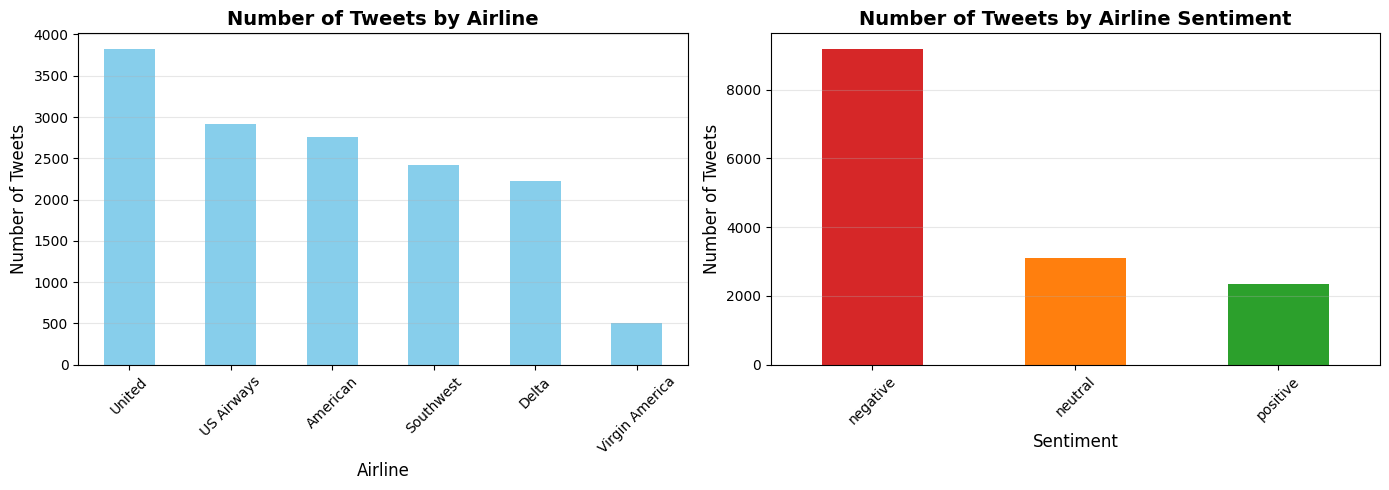

Total number of tweets: 14640

Tweets by Airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

Tweets by Sentiment:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [24]:
# Plot 1: Number of tweets by airline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count tweets by airline
airline_counts = df['airline'].value_counts()
airline_counts.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Tweets by Airline', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Airline', fontsize=12)
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Number of tweets by airline sentiment
sentiment_counts = df['airline_sentiment'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c']  # red, orange, green
sentiment_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Number of Tweets by Airline Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment', fontsize=12)
axes[1].set_ylabel('Number of Tweets', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total number of tweets: {len(df)}")
print(f"\nTweets by Airline:\n{airline_counts}")
print(f"\nTweets by Sentiment:\n{sentiment_counts}")

In [25]:
# Compute sentiment totals per airline and determine most hated / most loved
sentiment_by_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
print('Sentiment counts by airline:')
print(sentiment_by_airline)

most_hated_airline = sentiment_by_airline['negative'].idxmax()
most_hated_count = sentiment_by_airline['negative'].max()
most_loved_airline = sentiment_by_airline['positive'].idxmax()
most_loved_count = sentiment_by_airline['positive'].max()

print('\nMost hated airline (highest negative tweets):')
print(f'- {most_hated_airline} ({most_hated_count} negative tweets)')

print('\nMost loved airline (highest positive tweets):')
print(f'- {most_loved_airline} ({most_loved_count} positive tweets)')

Sentiment counts by airline:
airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152

Most hated airline (highest negative tweets):
- United (2633 negative tweets)

Most loved airline (highest positive tweets):
- Southwest (570 positive tweets)


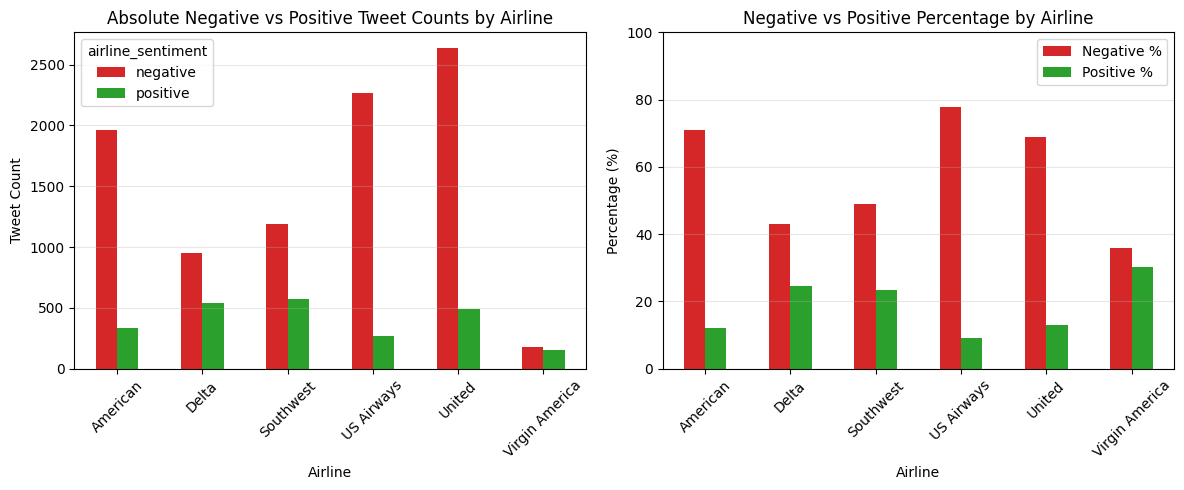


Most hated (highest absolute negative): United
Most loved (highest absolute positive): Southwest

Hate/Love percentages by airline (sorted by negative % descending):
airline_sentiment  negative_pct  positive_pct
airline                                      
US Airways            77.686234      9.234466
American              71.040232     12.178325
United                68.890633     12.872841
Southwest             49.008264     23.553719
Delta                 42.979298     24.482448
Virgin America        35.912698     30.158730


In [26]:
# Visualize most hated / most loved by airline with percent-based sentiment
sentiment_by_airline = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)

# Add totals and percentages
sentiment_by_airline['total'] = sentiment_by_airline.sum(axis=1)
sentiment_by_airline['positive_pct'] = sentiment_by_airline['positive'] / sentiment_by_airline['total'] * 100
sentiment_by_airline['negative_pct'] = sentiment_by_airline['negative'] / sentiment_by_airline['total'] * 100

# Plot absolute counts side-by-side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sentiment_by_airline[['negative', 'positive']].plot(kind='bar', stacked=False, color=['#d62728', '#2ca02c'], ax=plt.gca())
plt.title('Absolute Negative vs Positive Tweet Counts by Airline')
plt.xlabel('Airline')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Plot percentage sentiment so haters/lovers per brand are visible
plt.subplot(1, 2, 2)
ax = sentiment_by_airline[['negative_pct', 'positive_pct']].plot(kind='bar', stacked=False, color=['#d62728', '#2ca02c'], ax=plt.gca())
ax.set_title('Negative vs Positive Percentage by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.legend(['Negative %', 'Positive %'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Annotate and display ranked results for clarity
print('\nMost hated (highest absolute negative):', most_hated_airline)
print('Most loved (highest absolute positive):', most_loved_airline)
print('\nHate/Love percentages by airline (sorted by negative % descending):')
print(sentiment_by_airline[['negative_pct', 'positive_pct']].sort_values('negative_pct', ascending=False))

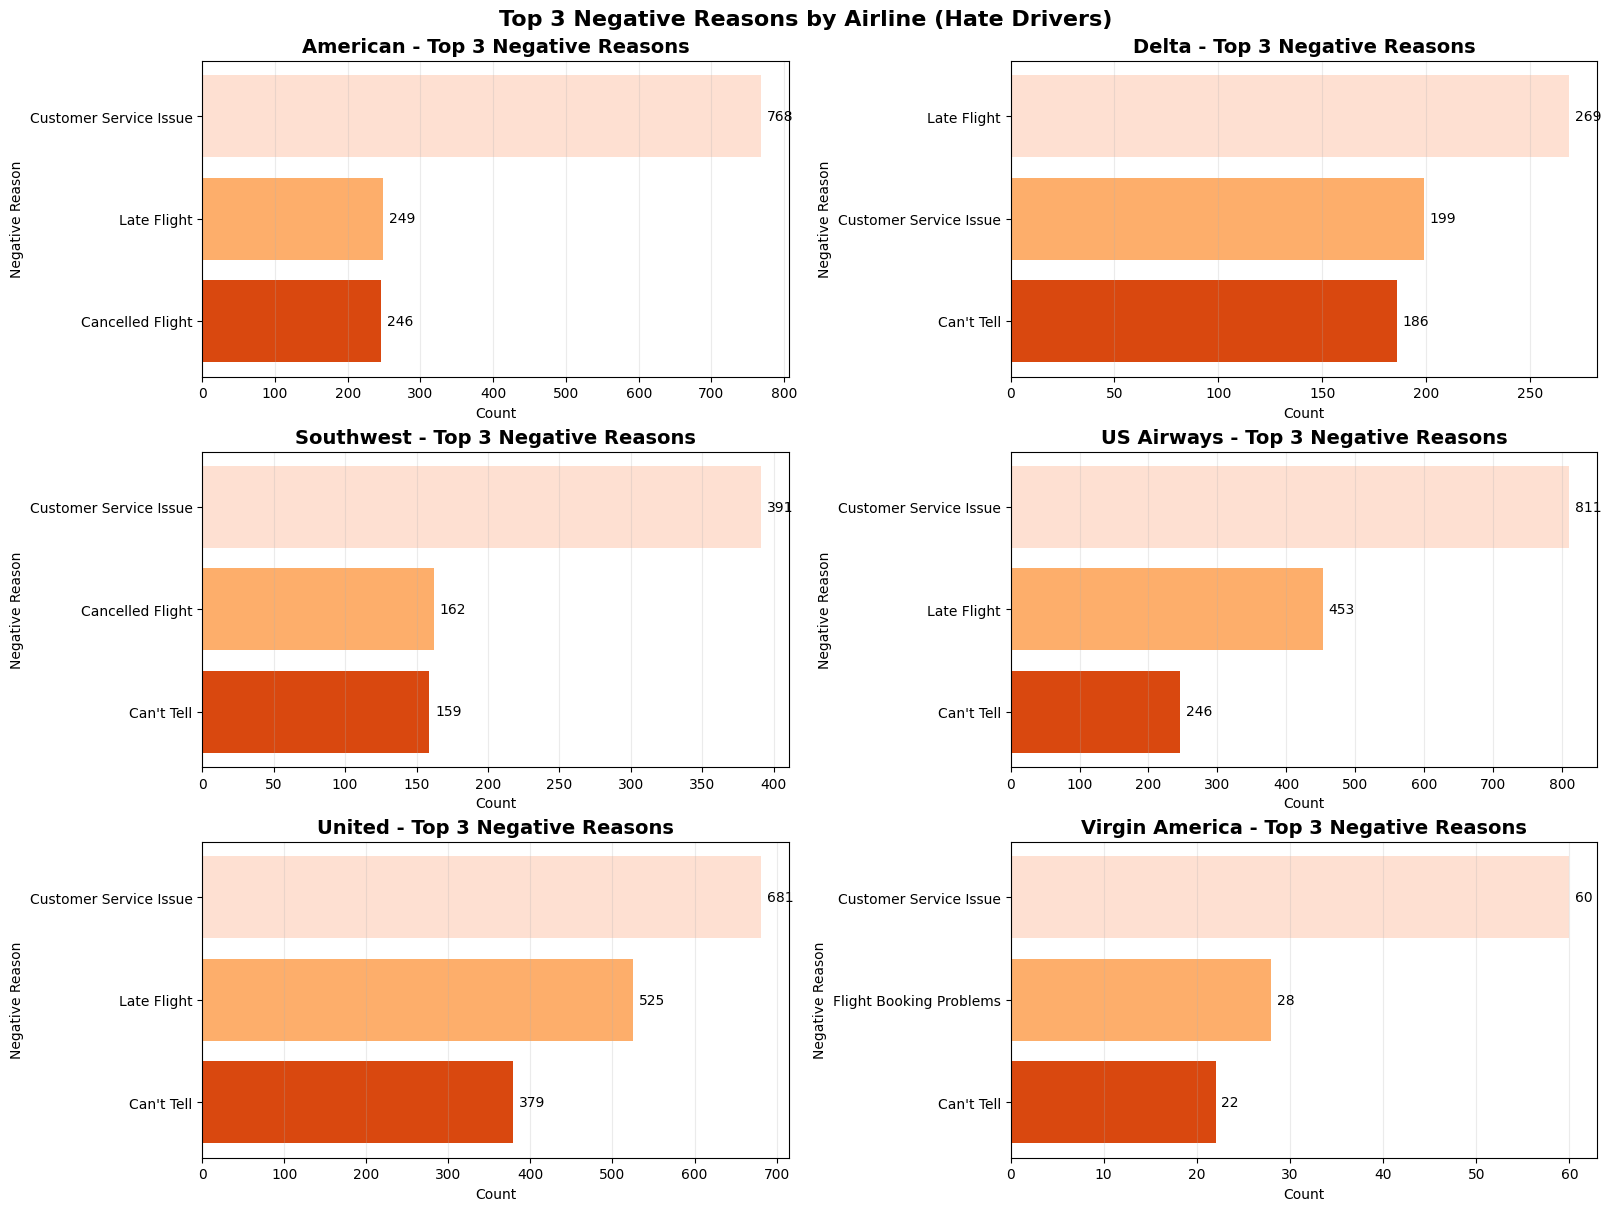

In [28]:
# Draw each airline's top 3 negative reasons in a consistent horizontal bar grid layout (aligned to your example image)
# Ensure `top3_reasons` is defined (recompute if kernel restarted)
if 'top3_reasons' not in globals():
    reason_by_airline = df[df['airline_sentiment'] == 'negative'].groupby(['airline', 'negativereason']).size().reset_index(name='count')
    top3_reasons = reason_by_airline.sort_values(['airline','count'], ascending=[True, False]).groupby('airline').head(3)

airline_list = top3_reasons['airline'].unique()
num_airlines = len(airline_list)
cols = 2
rows = (num_airlines + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4), constrained_layout=True)
axes = axes.flatten()

for i, airline in enumerate(airline_list):
    ax = axes[i]
    data = top3_reasons[top3_reasons['airline'] == airline].sort_values('count', ascending=True)
    ax.barh(data['negativereason'], data['count'], color=['#d9480f', '#fdae6b', '#fee0d2'])
    ax.set_title(f'{airline} - Top 3 Negative Reasons', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('Negative Reason')
    for j, v in enumerate(data['count']):
        ax.text(v + max(data['count']) * 0.01, j, str(v), va='center', fontsize=10)
    ax.grid(axis='x', alpha=0.25)

# Hide extra axes if present
for i in range(num_airlines, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Top 3 Negative Reasons by Airline (Hate Drivers)', fontsize=16, fontweight='bold')
plt.show()

Training Logistic Regression...
Training Random Forest...
LR test accuracy: 0.8296, RF test accuracy: 0.8173

Top n-grams gợi ý giận dữ (Logistic Regression, coef dương):
              ngram      coef
13144          suck  2.334103
14863         worst  2.297049
12386         screw  2.287955
13395      terrible  2.176716
727             bad  2.148402
8137           fuck  2.112395
9626            lie  2.067403
8970            hrs  1.961477
4494        delayed  1.960336
8833           hour  1.934439
8459           hang  1.926953
76       acceptable  1.847168
12115    ridiculous  1.811011
13120         stuck  1.801341
12188          rude  1.788827
9925        luggage  1.783359
12207          ruin  1.757015
8126      frustrate  1.703510
14164  unacceptable  1.696743
10657          nope  1.619157
14335       useless  1.616421
4185          delay  1.589697
9834           lose  1.587200
14782            wo  1.583204
8508           hate  1.549740

Top n-grams gợi thích nghi (không giận dữ):
    

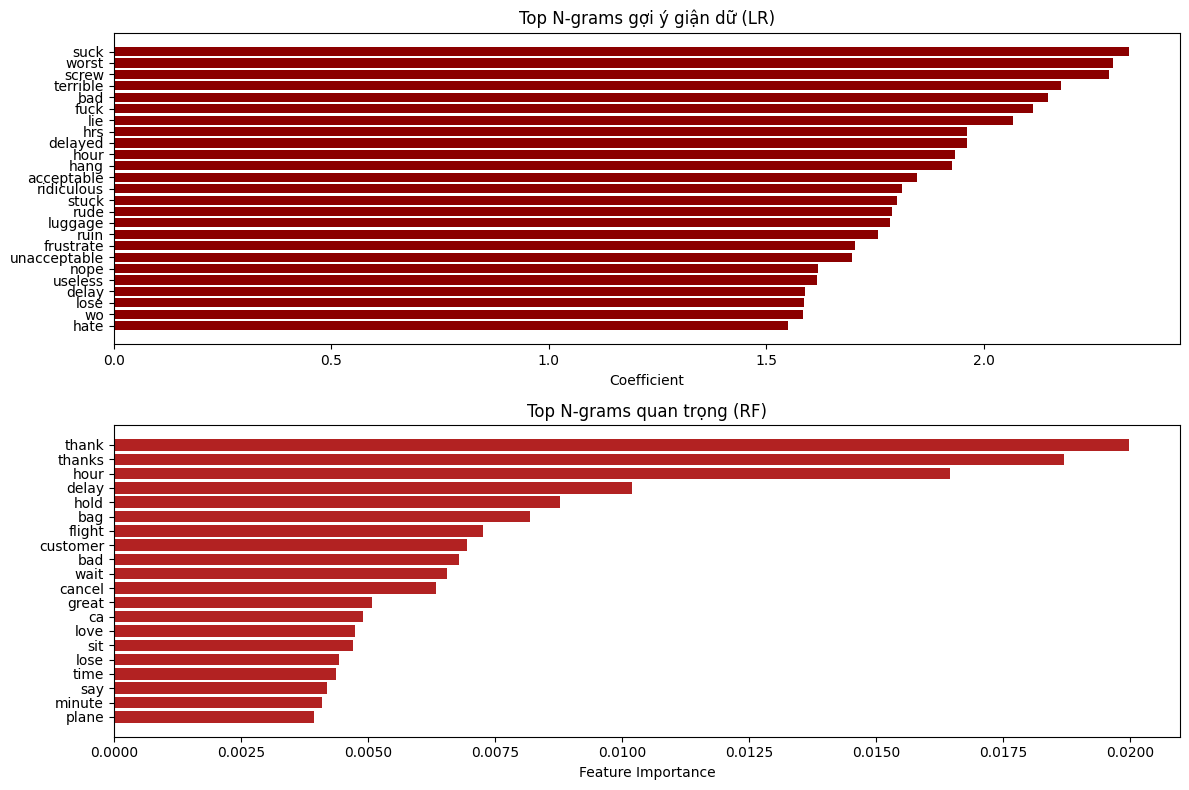


Ghi chú phân tích:
- Những từ/cụm từ bộc lộ giận dữ có thể bao gồm mentions tới lỗi dịch vụ, delay, cancel, complaint, anger v.v.
- Các khoá xác định có thể khác nhau nếu dùng nhằm so sánh brand A vs B bằng cách lọc theo airline và lặp lại pipeline.


In [29]:
# Liên kết text với airline_sentiment: trích xuất n-grams biểu hiện giận dữ
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Chọn cột text đã xử lý (text_preprocessed nếu có, ngược lại text)
text_col = 'text_preprocessed' if 'text_preprocessed' in df.columns else 'text'

# Gán nhãn: negative = 1, others = 0
X = df[text_col].fillna('')
y = (df['airline_sentiment'] == 'negative').astype(int)

# Chia train/test để ước đoán và đánh giá
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline LR
lr_pipeline = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Pipeline RF
rf_pipeline = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1))
])

print('Training Logistic Regression...')
lr_pipeline.fit(X_train, y_train)
print('Training Random Forest...')
rf_pipeline.fit(X_train, y_train)

# In ra một số độ chính xác
lr_score = lr_pipeline.score(X_test, y_test)
rf_score = rf_pipeline.score(X_test, y_test)
print(f'LR test accuracy: {lr_score:.4f}, RF test accuracy: {rf_score:.4f}')

# Trích n-gram quan trọng từ Logistic Regression
vectorizer = lr_pipeline.named_steps['vect']
lr_coef = lr_pipeline.named_steps['clf'].coef_[0]
feature_names = np.array(vectorizer.get_feature_names_out())

topn = 25
coef_df = pd.DataFrame({'ngram': feature_names, 'coef': lr_coef})
coef_df['abs_coef'] = coef_df['coef'].abs()

# N-gram hàng đầu với coefficient dương (gợi ý giận dữ)
top_negative_ngrams = coef_df.sort_values('coef', ascending=False).head(topn)
print('\nTop n-grams gợi ý giận dữ (Logistic Regression, coef dương):')
print(top_negative_ngrams[['ngram','coef']])

# n-gram với coefficient âm (gợi ý không giận dữ) để so sánh
top_non_negative_ngrams = coef_df.sort_values('coef', ascending=True).head(15)
print('\nTop n-grams gợi thích nghi (không giận dữ):')
print(top_non_negative_ngrams[['ngram','coef']])

# Từ Random Forest: feature importance
rf_vectorizer = rf_pipeline.named_steps['vect']
rf_importances = rf_pipeline.named_steps['clf'].feature_importances_
rf_feature_names = np.array(rf_vectorizer.get_feature_names_out())
rf_df = pd.DataFrame({'ngram': rf_feature_names, 'importance': rf_importances})
rf_top = rf_df.sort_values('importance', ascending=False).head(20)
print('\nTop n-grams (Random Forest importance):')
print(rf_top)

# Vẽ n-grams đặc trưng (LR & RF)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_negative_ngrams['ngram'][::-1], top_negative_ngrams['coef'][::-1], color='darkred')
plt.title('Top N-grams gợi ý giận dữ (LR)')
plt.xlabel('Coefficient')
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.barh(rf_top['ngram'][::-1], rf_top['importance'][::-1], color='firebrick')
plt.title('Top N-grams quan trọng (RF)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print('\nGhi chú phân tích:')
print('- Những từ/cụm từ bộc lộ giận dữ có thể bao gồm mentions tới lỗi dịch vụ, delay, cancel, complaint, anger v.v.')
print('- Các khoá xác định có thể khác nhau nếu dùng nhằm so sánh brand A vs B bằng cách lọc theo airline và lặp lại pipeline.')


=== Airline: Virgin America ===
Top n-grams liên quan giận dữ: ['site', 'website', 'seat', 'try', 'delayed', 'luggage', 'suck', 'email', 'bad', 'cancel']
Top n-grams không giận: ['love', 'thanks', 'great', 'cool', 'route', 'team', 'best', 'new', 'austin', 'dal']

=== Airline: United ===
Top n-grams liên quan giận dữ: ['charge', 'say', 'delay', 'bad', 'hour', 'wifi', 'people', 'terrible', 'min', 'miss']
Top n-grams không giận: ['thank', 'thanks', 'awesome', 'hi', 'try flight', 'compliment', 'love', 'thx', 'amaze', 'wonderful']

=== Airline: Southwest ===
Top n-grams liên quan giận dữ: ['bag', 'luggage', 'hold', 'hour', 'bad', 'delay', 'lose', 'sit', 'wifi', 'phone']
Top n-grams không giận: ['thank', 'awesome', 'best', 'thanks', 'ca wait', 'atlanta', 'love', 'chance', 'amaze', 'crew']

=== Airline: Delta ===
Top n-grams liên quan giận dữ: ['hour', 'delay', 'stop', 'delayed', 'suck', 'hate', 'respond', 'tv', 'plane', 'gate change']
Top n-grams không giận: ['thanks', 'thank', 'love', 'gre

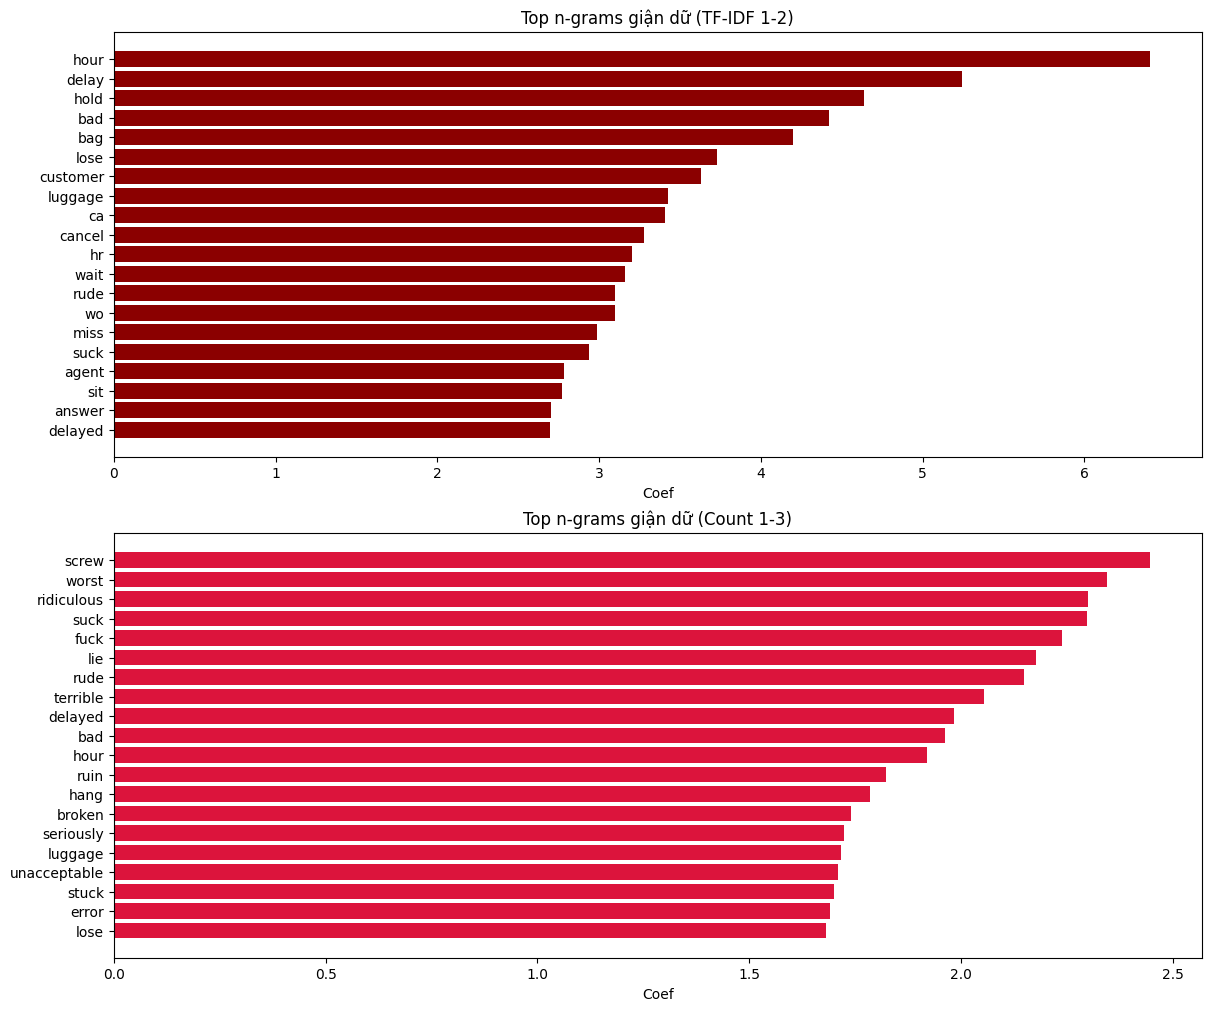

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Hàm hỗ trợ train & in top ngrams
def extract_ngrams_insight(X, y, vectorizer, topn=15):
    pipe = Pipeline([
        ('vect', vectorizer),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ])
    pipe.fit(X, y)
    if hasattr(pipe.named_steps['clf'], 'coef_'):
        coef = pipe.named_steps['clf'].coef_[0]
        names = np.array(pipe.named_steps['vect'].get_feature_names_out())
        coef_df = pd.DataFrame({'ngram': names, 'coef': coef})
        top_negative = coef_df.sort_values('coef', ascending=False).head(topn)
        top_positive = coef_df.sort_values('coef', ascending=True).head(topn)
        return pipe, top_negative, top_positive
    return pipe, None, None

# 1. So sánh theo airline (định nghĩa A vs B): lọc mỗi airline và trích ra ngrams tiêu biểu
for airline in df['airline'].unique():
    print(f"\n=== Airline: {airline} ===")
    df_sub = df[df['airline'] == airline]
    X_sub = df_sub[text_col].fillna('')
    y_sub = (df_sub['airline_sentiment'] == 'negative').astype(int)
    if y_sub.nunique() < 2 or len(df_sub) < 50:
        print('Không đủ dữ liệu để huấn luyện.')
        continue

    _, top_neg, top_pos = extract_ngrams_insight(X_sub, y_sub, CountVectorizer(ngram_range=(1,2), max_features=8000, stop_words='english'), topn=10)
    print('Top n-grams liên quan giận dữ:', top_neg['ngram'].tolist())
    print('Top n-grams không giận:', top_pos['ngram'].tolist())

# 2. Dùng TF-IDF thay Count (ngram range 1-2) trên toàn bộ dataset
print('\n=== TF-IDF ngram 1-2 (toàn bộ dataset) ===')
_, top_neg_tfidf, top_pos_tfidf = extract_ngrams_insight(X, y, TfidfVectorizer(ngram_range=(1,2), max_features=15000, stop_words='english'), topn=20)
print('Top n-grams giận dữ (TF-IDF):')
print(top_neg_tfidf[['ngram','coef']])
print('Top n-grams không giận (TF-IDF):')
print(top_pos_tfidf[['ngram','coef']])

# 3. Mở rộng ngram đến 3-grams (CountVectorizer + Logistic Regression)
print('\n=== CountVectorizer ngram 1-3 (toàn bộ dataset) ===')
_, top_neg_13, top_pos_13 = extract_ngrams_insight(X, y, CountVectorizer(ngram_range=(1,3), max_features=15000, stop_words='english'), topn=20)
print('Top n-grams giận dữ (1-3):')
print(top_neg_13[['ngram','coef']])
print('Top n-grams không giận (1-3):')
print(top_pos_13[['ngram','coef']])

# Vẽ kết quả comparison cho TF-IDF và 1-3 ngrams để xem nhanh
fig, axes = plt.subplots(2, 1, figsize=(12, 10), constrained_layout=True)
axes[0].barh(top_neg_tfidf['ngram'][::-1], top_neg_tfidf['coef'][::-1], color='darkred')
axes[0].set_title('Top n-grams giận dữ (TF-IDF 1-2)')
axes[0].set_xlabel('Coef')
axes[1].barh(top_neg_13['ngram'][::-1], top_neg_13['coef'][::-1], color='crimson')
axes[1].set_title('Top n-grams giận dữ (Count 1-3)')
axes[1].set_xlabel('Coef')
plt.show()

Parsing tweet_created and computing daily negative tweet counts...
No strong z-score spikes found (z>3). Reporting top absolute days instead.

Summary: daily negative tweets (showing tail)
tweet_created_dt
2015-02-16 00:00:00-08:00       3
2015-02-17 00:00:00-08:00     838
2015-02-18 00:00:00-08:00     736
2015-02-19 00:00:00-08:00     751
2015-02-20 00:00:00-08:00     835
2015-02-21 00:00:00-08:00    1049
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-24 00:00:00-08:00     781
Freq: D, Name: tweet_id, dtype: int64

Detected spike days (z>3):
Series([], Freq: D, Name: tweet_id, dtype: float64)

Top spike days (by count):
tweet_created_dt
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-21 00:00:00-08:00    1049
2015-02-17 00:00:00-08:00     838
2015-02-20 00:00:00-08:00     835
2015-02-24 00:00:00-08:00     781
2015-02-19 00:00:00-08:00     751
2015-02-18 00:00:00-08:00     736
2015-02-16 00:00:00-08:00       3
Name: tweet_id, dty

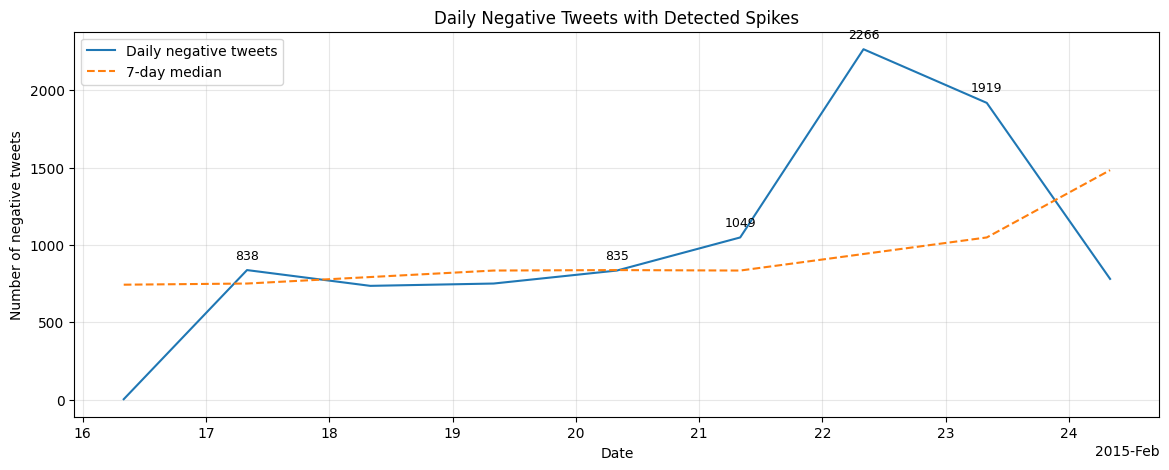


Sample tweets from top spike days:

=== 2015-02-22 — 2266 negative tweets ===
- use another browser brand reputation build tech response compatible website
- flight flight book problem site totally folk problem
- like customer service min delay connect passenger seem long
- need change flight thats schedule hour min wait time phone im call intern help
- fail customer check process link tsa

=== 2015-02-23 — 1919 negative tweets ===
- hi bked cool birthday trip ca add elevate cause enter middle name flight booking problem
- help leave expensive headphone flight iad lax today seat one answer number lax
- await return phone call would prefer use online option
- chat support work site
- hey first time flyer next week excite hard time get flight add elevate account help

=== 2015-02-21 — 1049 negative tweets ===
- congrats get business ewr fuck clincher
- apply week ago hear back fly week
- many apology worse airline even respond cudtomers
- shame va make people spend money strand city air

In [31]:
# Time-series analysis: detect negative-tweet spikes by date
# Parse datetimes, compute daily negative tweet counts, detect spikes (z > 3 vs 7-day median)
print('Parsing tweet_created and computing daily negative tweet counts...')

df['tweet_created_dt'] = pd.to_datetime(df['tweet_created'], errors='coerce')
neg = df[df['airline_sentiment'] == 'negative'].copy()
neg = neg.dropna(subset=['tweet_created_dt'])
neg.set_index('tweet_created_dt', inplace=True)

daily = neg['tweet_id'].resample('D').count()
# ensure full date range (fills zeros for missing days)
daily = daily.asfreq('D', fill_value=0)

# Rolling baseline (7-day median) and std for robust z-score
rolling_median = daily.rolling(window=7, min_periods=1, center=True).median()
rolling_std = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)

# z-score against median baseline
z = (daily - rolling_median) / rolling_std.replace(0, np.nan)
spike_series = z[z > 3].dropna()

# If no z>3 spikes detected, also report top days by absolute count
if spike_series.empty:
    print('No strong z-score spikes found (z>3). Reporting top absolute days instead.')
    top_spikes = daily.nlargest(10)
else:
    top_spikes = daily.loc[spike_series.index].sort_values(ascending=False)

# Print summary
print('\nSummary: daily negative tweets (showing tail)')
print(daily.tail(10))

print('\nDetected spike days (z>3):')
print(spike_series.sort_values(ascending=False).head(20))

print('\nTop spike days (by count):')
print(top_spikes.head(20))

# Plot daily counts, baseline, and spikes
import matplotlib.dates as mdates
plt.figure(figsize=(14,5))
plt.plot(daily.index, daily.values, label='Daily negative tweets', color='tab:blue')
plt.plot(rolling_median.index, rolling_median.values, label='7-day median', linestyle='--', color='tab:orange')
if not spike_series.empty:
    plt.scatter(spike_series.index, daily.loc[spike_series.index], color='red', label='Spikes (z>3)', zorder=5)

# annotate top spike day
for dt, val in top_spikes.head(5).items():
    plt.annotate(f'{val}', xy=(pd.to_datetime(dt), val), xytext=(0,8), textcoords='offset points', ha='center', fontsize=9)

plt.title('Daily Negative Tweets with Detected Spikes')
plt.xlabel('Date')
plt.ylabel('Number of negative tweets')
plt.legend()
plt.grid(alpha=0.3)
# prettier x-axis formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()

# Show sample tweets for top spike days to help identify cause
print('\nSample tweets from top spike days:')
for dt in top_spikes.head(5).index:
    day = pd.to_datetime(dt).date()
    subset = neg[neg.index.date == day]
    print(f"\n=== {day} — {len(subset)} negative tweets ===")
    # prefer `text_preprocessed` if available, else `text`
    text_col_pref = 'text_preprocessed' if 'text_preprocessed' in subset.columns else 'text'
    samples = subset[text_col_pref].dropna().head(5).tolist()
    for s in samples:
        print('-', s)
    if len(samples) == 0:
        print('  (no text available)')

# End of time-series spike analysis cell

Running expanded spike analysis (per-airline, hourly, export)...
Spike summary saved to data/spike_summary_by_airline.csv


,airline,date,count,z
2,American,2015-02-24,369,NaN
0,American,2015-02-23,826,NaN
13,United,2015-02-23,449,NaN
10,US Airways,2015-02-23,372,NaN
5,Delta,2015-02-23,125,NaN
16,Virgin America,2015-02-23,31,NaN
1,American,2015-02-22,762,NaN
9,US Airways,2015-02-22,561,NaN
12,United,2015-02-22,532,NaN
3,Delta,2015-02-22,255,NaN



Top overall negative days:
tweet_created_dt
2015-02-22 00:00:00-08:00    2266
2015-02-23 00:00:00-08:00    1919
2015-02-21 00:00:00-08:00    1049
Name: tweet_id, dtype: int64


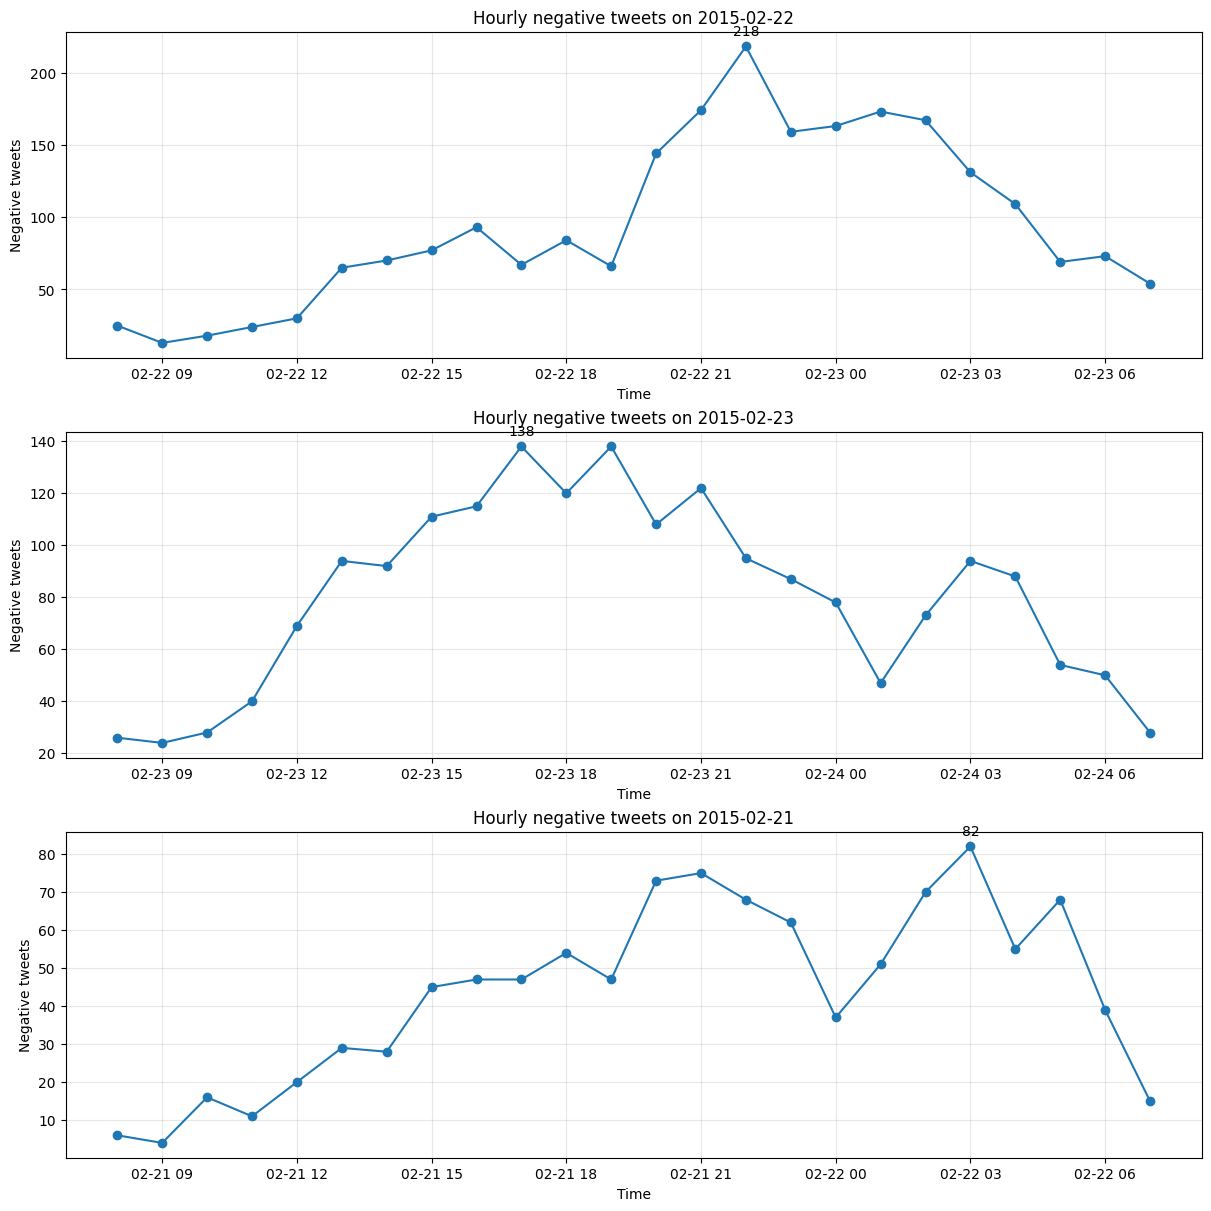

Overall top spike days saved to data/top_spike_days_overall.csv

Sample tweets for airline-specific spike days:

=== American — 2015-02-23 (1919 negative tweets) ===
- hi bked cool birthday trip ca add elevate cause enter middle name flight booking problem
- help leave expensive headphone flight iad lax today seat one answer number lax
- await return phone call would prefer use online option
- chat support work site
- hey first time flyer next week excite hard time get flight add elevate account help

=== Delta — 2015-02-22 (2266 negative tweets) ===
- use another browser brand reputation build tech response compatible website
- flight flight book problem site totally folk problem
- like customer service min delay connect passenger seem long
- need change flight thats schedule hour min wait time phone im call intern help
- fail customer check process link tsa

=== Southwest — 2015-02-21 (1049 negative tweets) ===
- congrats get business ewr fuck clincher
- apply week ago hear back fly 

In [32]:
# Expanded spike analysis: per-airline spikes, hourly breakdown for top days, and export CSV
import os
print('Running expanded spike analysis (per-airline, hourly, export)...')

# ensure tweet_created_dt exists
df['tweet_created_dt'] = pd.to_datetime(df['tweet_created'], errors='coerce')

spike_rows = []

for airline in sorted(df['airline'].dropna().unique()):
    sub = df[df['airline'] == airline].copy()
    sub['tweet_created_dt'] = pd.to_datetime(sub['tweet_created'], errors='coerce')
    sub_neg = sub[sub['airline_sentiment'] == 'negative'].dropna(subset=['tweet_created_dt'])
    if len(sub_neg) < 10:
        print(f'Skipping {airline}: too few negative tweets ({len(sub_neg)})')
        continue

    daily = sub_neg.set_index('tweet_created_dt')['tweet_id'].resample('D').count().asfreq('D', fill_value=0)
    rolling_median = daily.rolling(window=7, min_periods=1, center=True).median()
    rolling_std = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)
    z = (daily - rolling_median) / rolling_std.replace(0, np.nan)

    # define spikes
    spikes = z[z > 3]
    if spikes.empty:
        # fallback: top 3 absolute days for this airline
        top_days = daily.nlargest(3)
        for dt, cnt in top_days.items():
            spike_rows.append({'airline': airline, 'date': pd.to_datetime(dt).date(), 'count': int(cnt), 'z': float('nan')})
    else:
        for dt, zval in spikes.items():
            spike_rows.append({'airline': airline, 'date': pd.to_datetime(dt).date(), 'count': int(daily.loc[dt]), 'z': float(zval)})

# create summary DataFrame and save
spike_summary = pd.DataFrame(spike_rows)
if spike_summary.empty:
    print('No airline-specific spikes found.')
else:
    spike_summary = spike_summary.sort_values(['date','count'], ascending=[False, False])
    out_csv = 'data/spike_summary_by_airline.csv'
    spike_summary.to_csv(out_csv, index=False)
    print(f'Spike summary saved to {out_csv}')
    display(spike_summary.head(50))

# Hourly breakdown for top overall spike days (use previously computed daily from negative global data)
neg_all = df[df['airline_sentiment'] == 'negative'].copy()
neg_all = neg_all.dropna(subset=['tweet_created_dt'])
neg_all.set_index('tweet_created_dt', inplace=True)

daily_all = neg_all['tweet_id'].resample('D').count().asfreq('D', fill_value=0)

# choose top 3 days overall
top_overall = daily_all.nlargest(3)
print('\nTop overall negative days:')
print(top_overall)

# plot hourly for each top day
import math
top_days = [pd.to_datetime(idx).date() for idx in top_overall.index]
fig, axes = plt.subplots(len(top_days), 1, figsize=(12, 4 * len(top_days)), constrained_layout=True)
if len(top_days) == 1:
    axes = [axes]

for ax, day in zip(axes, top_days):
    # Use date-based selection to avoid tz-aware vs tz-naive comparison issues
    subset_day = neg_all[neg_all.index.date == day]
    if subset_day.empty:
        hourly = pd.Series(0, index=pd.date_range(start=pd.Timestamp(day), periods=24, freq='h'))
    else:
        # Resample hourly — make index tz-naive for consistent resampling
        idx = subset_day.index
        if getattr(idx, 'tz', None) is not None:
            # convert to UTC then remove tz info
            subset_day = subset_day.tz_convert('UTC')
            subset_day.index = subset_day.index.tz_localize(None)
        hourly = subset_day['tweet_id'].resample('h').count().asfreq('h', fill_value=0)

    ax.plot(hourly.index, hourly.values, marker='o')
    ax.set_title(f'Hourly negative tweets on {day}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Negative tweets')
    ax.grid(alpha=0.3)
    # annotate peak hour
    if len(hourly) > 0:
        peak_idx = hourly.idxmax()
        peak_val = int(hourly.max())
        if peak_val > 0:
            ax.annotate(f'{peak_val}', xy=(peak_idx, peak_val), xytext=(0,8), textcoords='offset points', ha='center')

plt.show()

# Save top overall days to CSV for external comparison (C)
out_overall = 'data/top_spike_days_overall.csv'
top_overall_df = top_overall.reset_index()
top_overall_df.columns = ['date','count']
# convert date to date-only
top_overall_df['date'] = top_overall_df['date'].dt.date
top_overall_df.to_csv(out_overall, index=False)
print(f'Overall top spike days saved to {out_overall}')

# Provide samples for each airline top spike day from spike_summary
if not spike_summary.empty:
    print('\nSample tweets for airline-specific spike days:')
    grouped = spike_summary.groupby('airline')
    for airline, group in grouped:
        top = group.sort_values('count', ascending=False).head(1).iloc[0]
        day = pd.to_datetime(top['date']).date()
        subset = neg_all[neg_all.index.date == day]
        print(f"\n=== {airline} — {day} ({len(subset)} negative tweets) ===")
        text_col_pref = 'text_preprocessed' if 'text_preprocessed' in df.columns else 'text'
        for s in subset[text_col_pref].dropna().head(5).tolist():
            print('-', s)

print('\nExpanded spike analysis complete.')

Comparing spikes for selected airlines...
Top airlines to compare: ['United', 'US Airways', 'American']


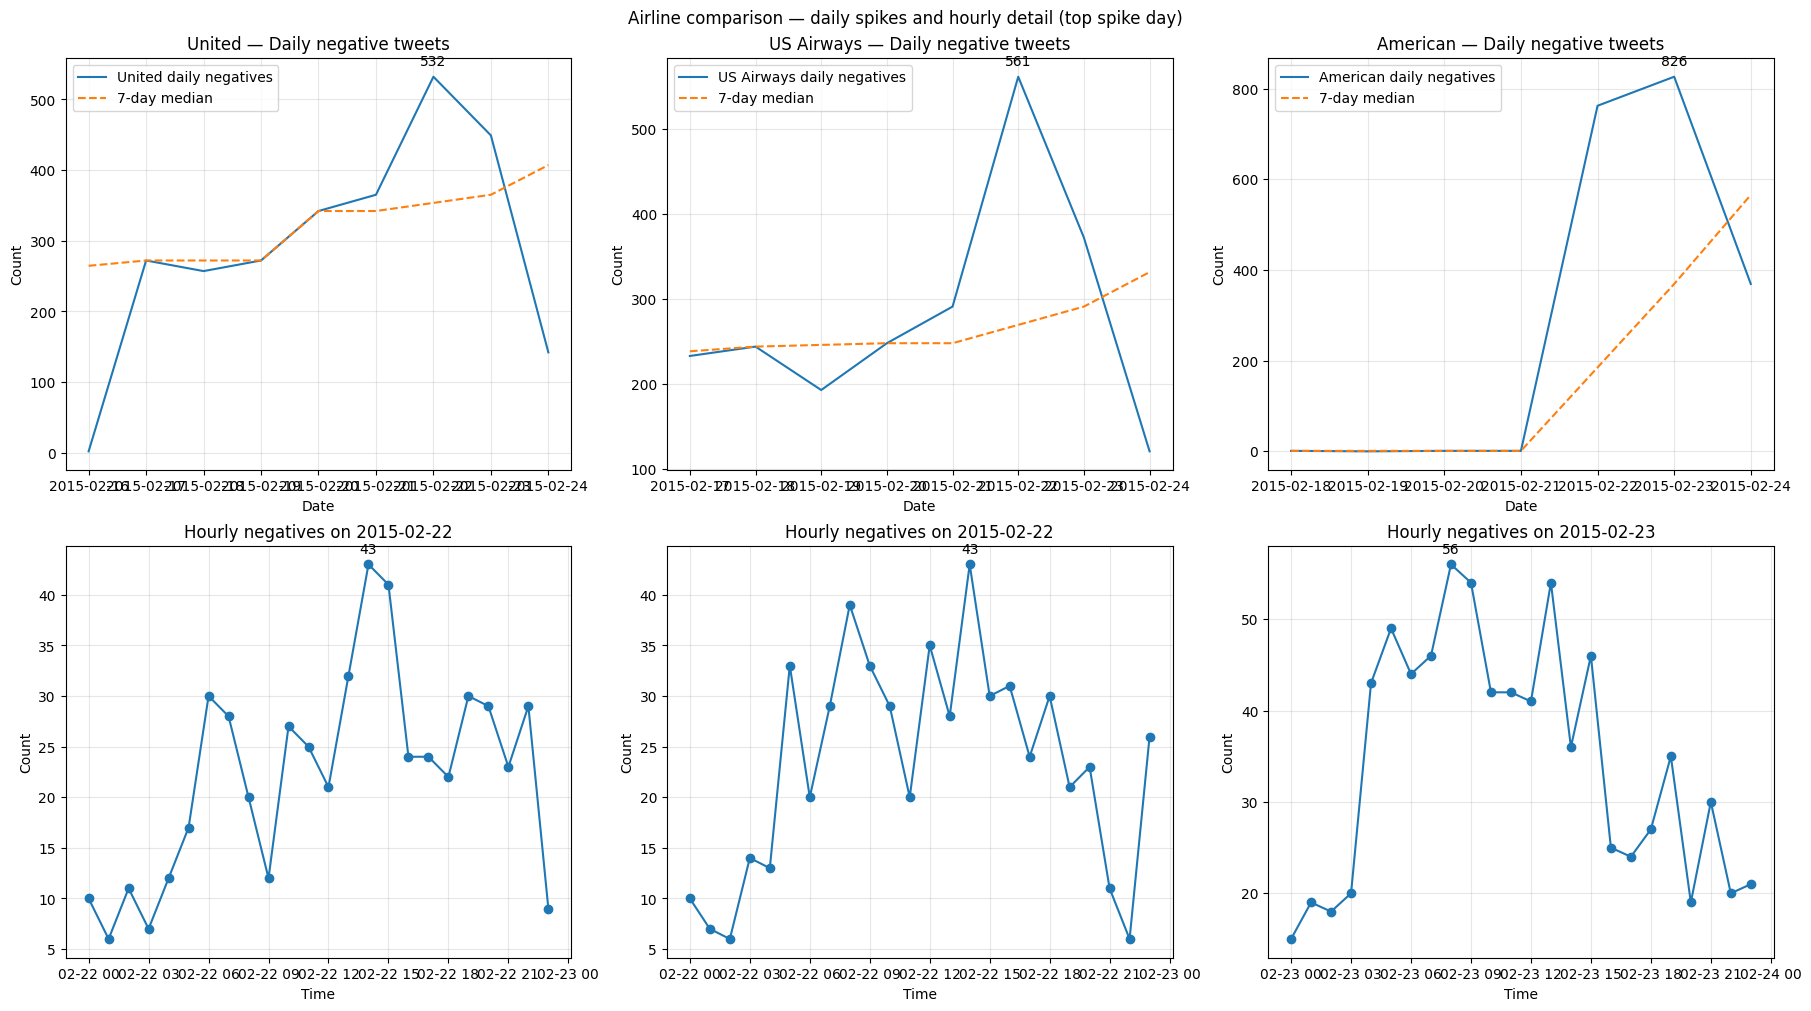

Saved comparison figure to data/airline_spike_comparison.png


In [33]:
# Compare spikes across selected airlines (side-by-side daily + hourly for top spike day)
print('Comparing spikes for selected airlines...')

# choose top 3 airlines by negative volume (from sentiment_by_airline computed earlier)
neg_counts = df[df['airline_sentiment']=='negative']['airline'].value_counts()
top_airlines = neg_counts.nlargest(3).index.tolist()
print('Top airlines to compare:', top_airlines)

# Prepare figure: 2 rows (daily, hourly) x N cols (airlines)
n = len(top_airlines)
fig, axes = plt.subplots(2, n, figsize=(6*n, 10), constrained_layout=True)
if n == 1:
    axes = axes.reshape(2,1)

for col, airline in enumerate(top_airlines):
    sub = df[df['airline'] == airline].copy()
    sub['tweet_created_dt'] = pd.to_datetime(sub['tweet_created'], errors='coerce')
    sub_neg = sub[sub['airline_sentiment'] == 'negative'].dropna(subset=['tweet_created_dt'])
    if sub_neg.empty:
        axes[0, col].text(0.5, 0.5, 'No data', ha='center')
        axes[1, col].text(0.5, 0.5, 'No data', ha='center')
        continue

    # daily time series and spikes
    daily = sub_neg.set_index('tweet_created_dt')['tweet_id'].resample('D').count().asfreq('D', fill_value=0)
    rm = daily.rolling(window=7, min_periods=1, center=True).median()
    rs = daily.rolling(window=7, min_periods=1, center=True).std().fillna(0)
    z = (daily - rm) / rs.replace(0, np.nan)
    spikes = z[z > 3]
    if spikes.empty:
        top_day = daily.idxmax()
    else:
        top_day = spikes.index[0]

    # Plot daily
    ax = axes[0, col]
    ax.plot(daily.index, daily.values, label=f'{airline} daily negatives', color='tab:blue')
    ax.plot(rm.index, rm.values, linestyle='--', color='tab:orange', label='7-day median')
    if not spikes.empty:
        ax.scatter(spikes.index, daily.loc[spikes.index], color='red', zorder=5, label='spikes (z>3)')
    ax.set_title(f'{airline} — Daily negative tweets')
    ax.set_xlabel('Date')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    ax.legend()
    # annotate top day
    try:
        top_val = int(daily.loc[top_day])
        ax.annotate(f'{top_val}', xy=(pd.to_datetime(top_day), top_val), xytext=(0,8), textcoords='offset points', ha='center')
    except Exception:
        pass

    # hourly plot for the top day
    ax2 = axes[1, col]
    day = pd.to_datetime(top_day)
    # select timezone-aware safely: compare dates
    day_date = day.date()
    subset_day = sub_neg[sub_neg['tweet_created_dt'].dt.date == day_date].copy()
    if subset_day.empty:
        ax2.text(0.5, 0.5, 'No hourly data', ha='center')
    else:
        idx = subset_day['tweet_created_dt']
        # normalize tz if present
        if getattr(idx.dt.tz, 'zone', None) is not None:
            subset_day['tweet_created_dt'] = subset_day['tweet_created_dt'].dt.tz_convert('UTC').dt.tz_localize(None)
        subset_day = subset_day.set_index('tweet_created_dt')
        hourly = subset_day['tweet_id'].resample('h').count().asfreq('h', fill_value=0)
        ax2.plot(hourly.index, hourly.values, marker='o')
        ax2.set_title(f'Hourly negatives on {day_date}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Count')
        ax2.grid(alpha=0.3)
        # annotate peak
        peak = int(hourly.max())
        if peak > 0:
            ax2.annotate(f'{peak}', xy=(hourly.idxmax(), peak), xytext=(0,8), textcoords='offset points', ha='center')

plt.suptitle('Airline comparison — daily spikes and hourly detail (top spike day)')
plt.show()

# Save figure
out_fig = 'data/airline_spike_comparison.png'
fig.savefig(out_fig, dpi=200)
print('Saved comparison figure to', out_fig)

# mark todo item 4 completed


Analyzing retweet_count by sentiment...

Retweet count summary by sentiment:
                   count      mean  median       std
airline_sentiment                                   
negative            9178  0.093375     0.0  0.792865
neutral             3099  0.060987     0.0  0.658037
positive            2363  0.069403     0.0  0.659914

Log1p retweet stats by sentiment:
                       mean  median       std  count
airline_sentiment                                   
negative           0.050902     0.0  0.209118   9178
neutral            0.028327     0.0  0.178533   3099
positive           0.030960     0.0  0.192630   2363
Kruskal-Wallis H-test: H=77.539, p=1.45e-17


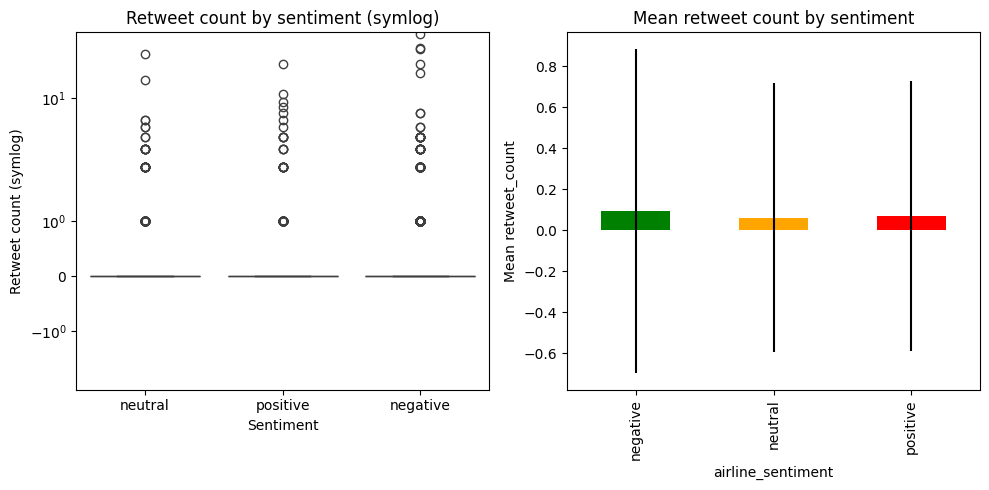


Top viral negative tweets (by retweet_count):

Retweets: 44, Airline: US Airways, Date: 2015-02-17 20:06:21 -0800
- @USAirways 5 hr flight delay and a delay when we land . Is that even real life ? Get me off this plane , I wanna go home 👠👠👠 (3 heel clicks)

Retweets: 32, Airline: US Airways, Date: 2015-02-17 20:50:56 -0800
- @USAirways of course never again tho . Thanks for tweetin ur concern but not Doin anythin to fix what happened. I'll choose wiser next time

Retweets: 31, Airline: Delta, Date: 2015-02-23 10:30:29 -0800
- STOP. USING.THIS.WORD. IF. YOU'RE. A. COMPANY. RT @JetBlue: Our fleet's on fleek. http://t.co/Fd2TNYcTrB

Retweets: 22, Airline: Delta, Date: 2015-02-23 10:51:54 -0800
- can you not? RT @JetBlue Our fleet's on fleek. http://t.co/413GiAL0yl

Retweets: 18, Airline: Delta, Date: 2015-02-23 12:04:21 -0800
- Just in case you needed confirmation that "on fleek" is dead &amp; gone. RT @JetBlue: Our fleet's on fleek. http://t.co/G4O6yX7TMJ

Retweets: 7, Airline: United, 

In [34]:
# Compare retweet_count across sentiment groups and show viral negative tweets
print('Analyzing retweet_count by sentiment...')

# Ensure retweet_count exists and is numeric
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0).astype(int)

groups = df.groupby('airline_sentiment')['retweet_count'].agg(['count','mean','median','std'])
print('\nRetweet count summary by sentiment:')
print(groups)

# Also compute mean and median with log1p transform to handle skew
df['retweet_log1p'] = np.log1p(df['retweet_count'])
log_stats = df.groupby('airline_sentiment')['retweet_log1p'].agg(['mean','median','std','count'])
print('\nLog1p retweet stats by sentiment:')
print(log_stats)

# Statistical test (Kruskal-Wallis non-parametric)
from scipy.stats import kruskal
neg = df[df['airline_sentiment']=='negative']['retweet_count']
neut = df[df['airline_sentiment']=='neutral']['retweet_count']
pos = df[df['airline_sentiment']=='positive']['retweet_count']

try:
    stat, p = kruskal(neg, neut, pos)
    print(f'Kruskal-Wallis H-test: H={stat:.3f}, p={p:.3g}')
except Exception as e:
    print('Kruskal-Wallis test failed:', e)

# Visualization: boxplot (log scale) and bar of means
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='airline_sentiment', y='retweet_count')
plt.yscale('symlog')
plt.title('Retweet count by sentiment (symlog)')
plt.xlabel('Sentiment')
plt.ylabel('Retweet count (symlog)')

plt.subplot(1,2,2)
means = df.groupby('airline_sentiment')['retweet_count'].mean()
stds = df.groupby('airline_sentiment')['retweet_count'].std()
means.plot(kind='bar', yerr=stds, color=['green','orange','red'])
plt.title('Mean retweet count by sentiment')
plt.ylabel('Mean retweet_count')
plt.tight_layout()
plt.show()

# Show top viral negative tweets
print('\nTop viral negative tweets (by retweet_count):')
neg_sorted = df[df['airline_sentiment']=='negative'].sort_values('retweet_count', ascending=False)
for _, row in neg_sorted.head(10).iterrows():
    print(f"\nRetweets: {row['retweet_count']}, Airline: {row.get('airline','')}, Date: {row.get('tweet_created','')}")
    text_col_pref = 'text' if 'text' in row.index else df.columns[0]
    print('-', row.get(text_col_pref, '')[:300])

# Save summary to CSV
out_csv = 'data/retweet_summary_by_sentiment.csv'
groups.to_csv(out_csv)
print(f'Grouped retweet summary saved to {out_csv}')